In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

ruta = "/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo"
os.chdir(ruta)

In [3]:
from sklearn import metrics
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler


(150.0, 550.0)

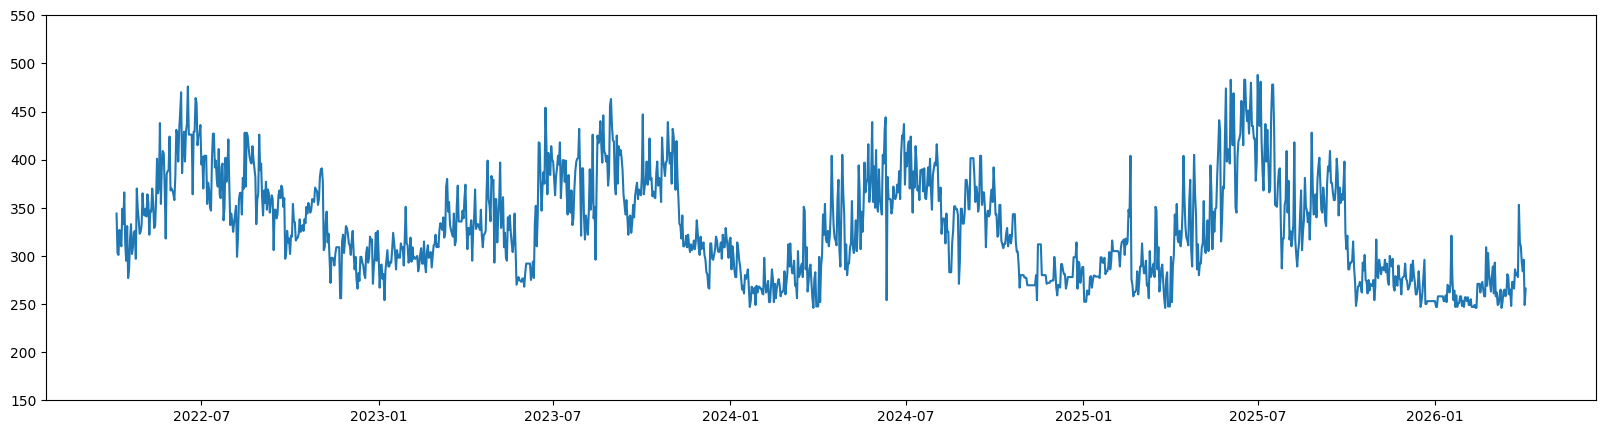

In [4]:
df = pd.read_csv('qDiarioAnálisis.csv',parse_dates=["StartDateTime"], index_col=["StartDateTime"])
df.index = df.index.date
plt.figure(figsize=(20,5))
plt.plot(df['Consumption'])
plt.ylim([150,550])

In [5]:
def plot_baseline(dates, y_true, y_pred, title):

    plt.figure(figsize=(12,5))

    plt.plot(dates, y_true, color="gray", label="Real")
    plt.plot(dates, y_pred, color="red", label="Predicción")

    plt.title(title)
    plt.legend(loc="upper left")

    n_ticks = 10
    idx = np.linspace(0, len(dates)-1, n_ticks, dtype=int)

    plt.xticks(dates[idx], rotation=45)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))

    plt.show()

In [6]:
def get_metrics(y_true, y_pred):

    r2 = metrics.r2_score(y_true, y_pred)
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = 100 * mae / np.average(y_true)

    return rmse, mae, mape

In [7]:
def baseline_persistence_scaled(df, target_col="Consumption", lag=1):

    df = df.copy()

    df["pred"] = df[target_col].shift(lag)

    split_idx = int(len(df) * 0.8)

    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:].dropna()

    scaler = MinMaxScaler()
    scaler.fit(train[target_col].values.reshape(-1,1))

    y_true = scaler.transform(test[target_col].values.reshape(-1,1)).flatten()
    y_pred = scaler.transform(test["pred"].values.reshape(-1,1)).flatten()

    dates = test.index

    return dates, y_true, y_pred

Lag 1 -> RMSE: 0.1057 | MAE: 0.0722 | MAPE: 26.99%


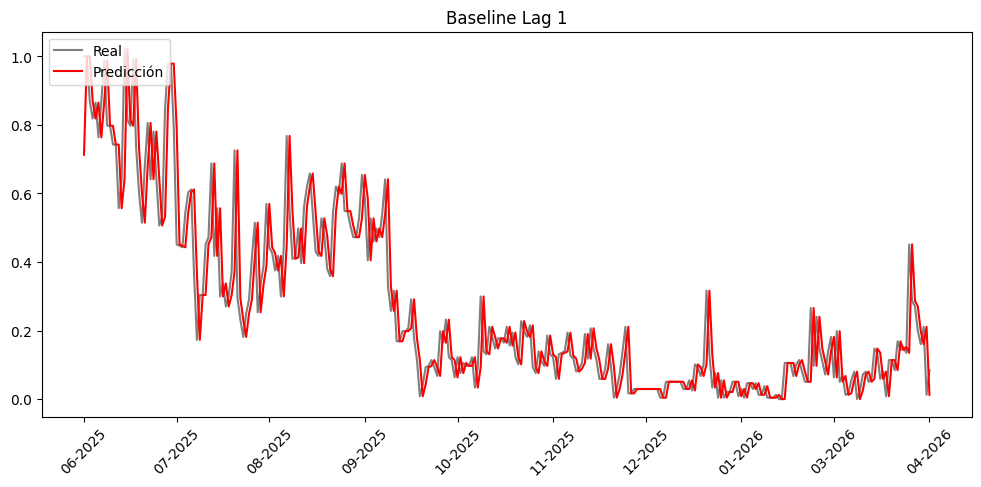

In [8]:
# Lag 1
dates1, y_true_1, y_pred_1 = baseline_persistence_scaled(df, lag=1)
rmse1, mae1, mape1 = get_metrics(y_true_1, y_pred_1)
print(f"Lag 1 -> RMSE: {rmse1:.4f} | MAE: {mae1:.4f} | MAPE: {mape1:.2f}%")
plot_baseline(dates1, y_true_1, y_pred_1, "Baseline Lag 1")

In [9]:
analysis = df[['Consumption']].copy()

analysis.index = pd.to_datetime(analysis.index)
analysis = analysis.asfreq('D')

In [10]:
decompose_result = seasonal_decompose(
    analysis,
    model="multiplicative",  # o "additive"
    period=7  # 🔥 clave → estacionalidad semanal
)

In [11]:
trend = decompose_result.trend
seasonal = decompose_result.seasonal
residual = decompose_result.resid

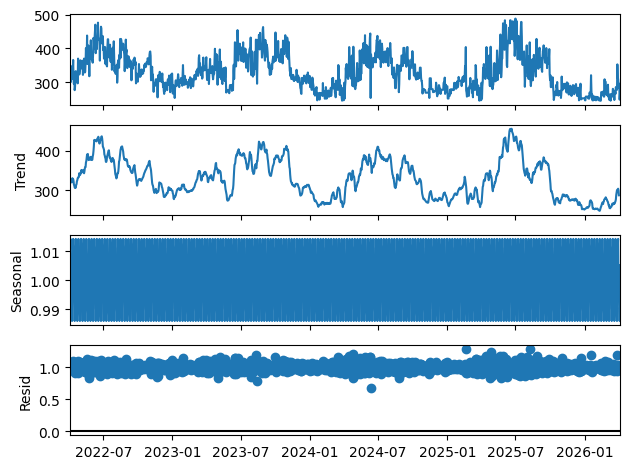

In [12]:
decompose_result.plot()
plt.show()

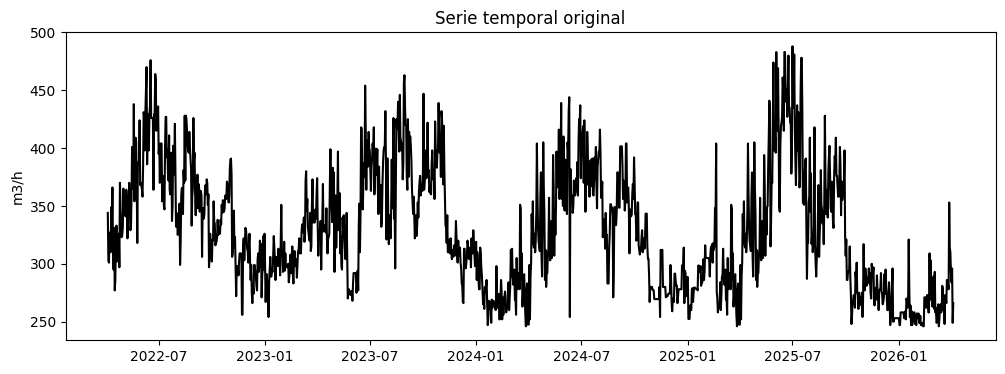

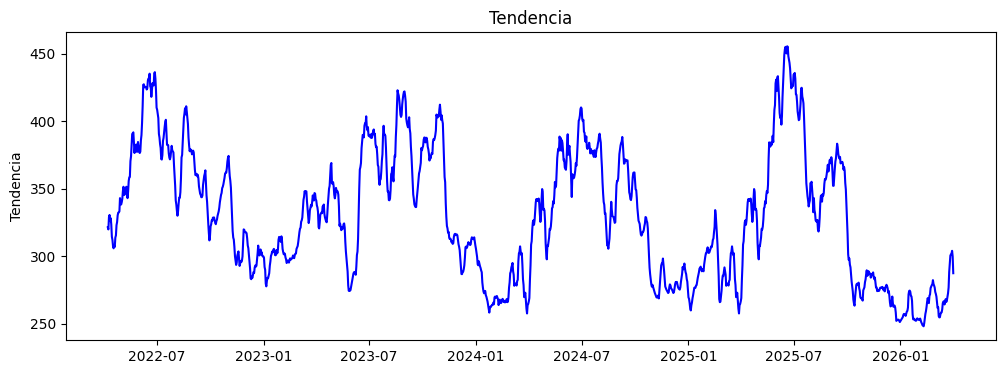

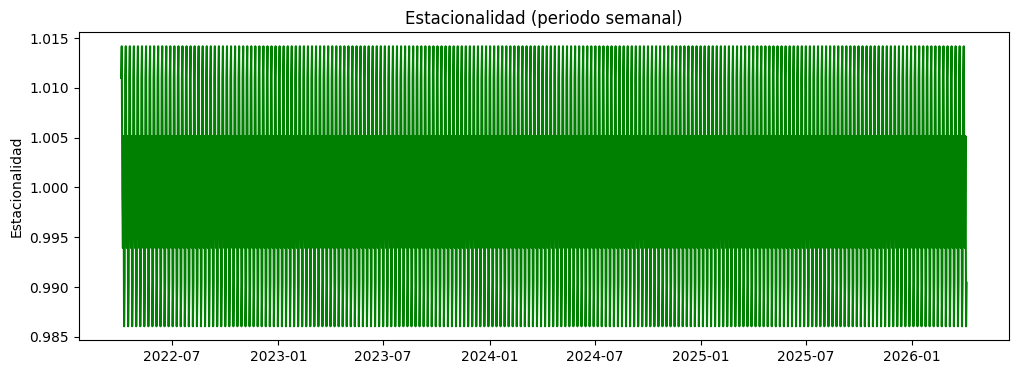

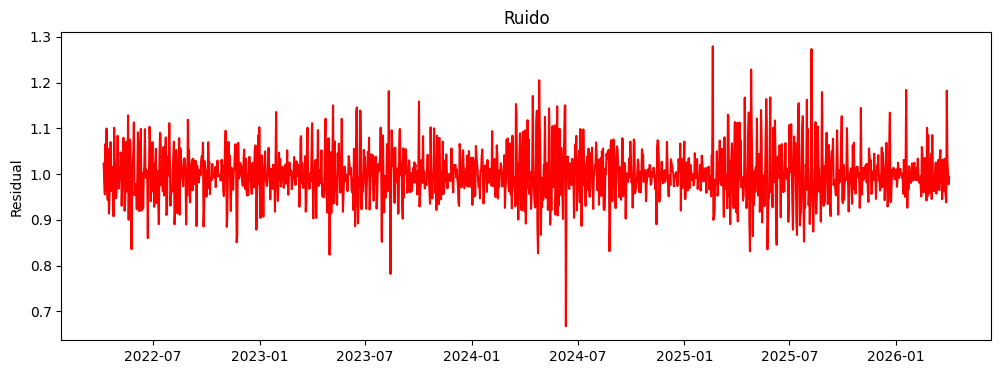

In [13]:
plt.figure(figsize=(12,4))
plt.plot(analysis, color="black")
plt.title("Serie temporal original")
plt.ylabel("m3/h")
plt.show()
plt.figure(figsize=(12,4))
plt.plot(trend, color="blue")
plt.title("Tendencia")
plt.ylabel("Tendencia")
plt.show()
plt.figure(figsize=(12,4))
plt.plot(seasonal, color="green")
plt.title("Estacionalidad (periodo semanal)")
plt.ylabel("Estacionalidad")
plt.show()
plt.figure(figsize=(12,4))
plt.plot(residual, color="red")
plt.title("Ruido")
plt.ylabel("Residual")
plt.show()

2024-02-01    0.993926
2024-02-02    1.005162
2024-02-03    0.986055
2024-02-04    0.990437
2024-02-05    1.010999
2024-02-06    1.014180
2024-02-07    0.999241
2024-02-08    0.993926
2024-02-09    1.005162
2024-02-10    0.986055
2024-02-11    0.990437
2024-02-12    1.010999
2024-02-13    1.014180
2024-02-14    0.999241
2024-02-15    0.993926
2024-02-16    1.005162
2024-02-17    0.986055
2024-02-18    0.990437
2024-02-19    1.010999
2024-02-20    1.014180
2024-02-21    0.999241
2024-02-22    0.993926
2024-02-23    1.005162
2024-02-24    0.986055
2024-02-25    0.990437
2024-02-26    1.010999
2024-02-27    1.014180
2024-02-28    0.999241
Freq: D, Name: seasonal, dtype: float64


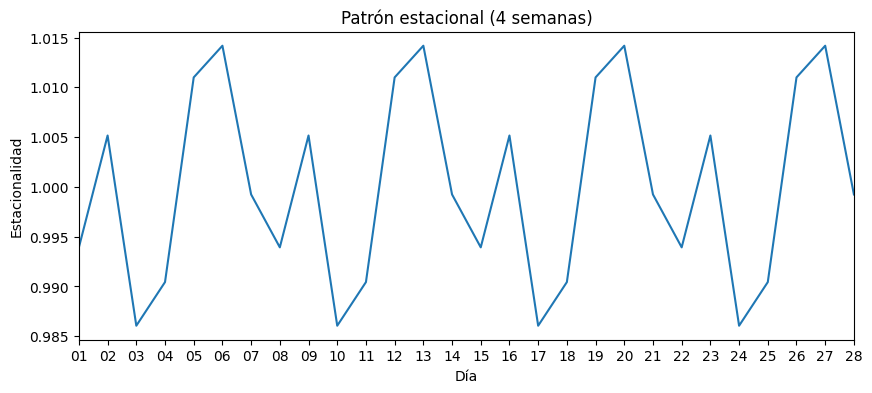

In [14]:
fig, ax = plt.subplots(figsize=(10,4))
print(seasonal.loc["2024-02-01":"2024-02-28"])
seasonal.loc["2024-02-01":"2024-02-28"].plot(ax=ax)

ax.set_title("Patrón estacional (4 semanas)")
ax.set_xlabel("Día")
ax.set_ylabel("Estacionalidad")

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d"))

plt.show()

Lag 7 -> RMSE: 0.1308 | MAE: 0.0943 | MAPE: 35.24%


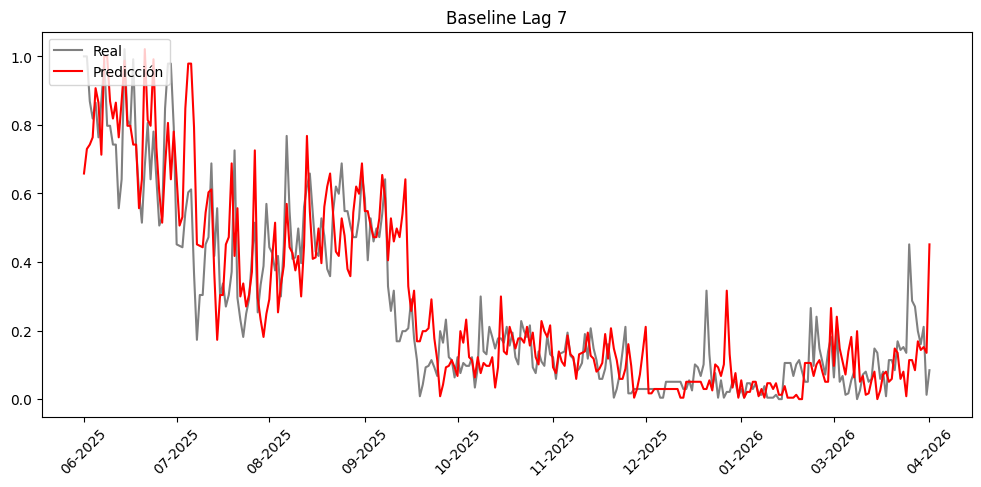

In [15]:
# Lag 7
dates7, y_true_7, y_pred_7 = baseline_persistence_scaled(df, lag=7)
rmse7, mae7, mape7 = get_metrics(y_true_7, y_pred_7)
print(f"Lag 7 -> RMSE: {rmse7:.4f} | MAE: {mae7:.4f} | MAPE: {mape7:.2f}%")
plot_baseline(dates7, y_true_7, y_pred_7, "Baseline Lag 7")

In [16]:
baseline_results = pd.DataFrame({
    "dataset": ["baseline_lag1", "baseline_lag7"],
    "cv_rmse": [None, None],  # baseline no tiene CV
    "cv_mae": [None, None],
    "cv_mape": [None, None],
    "test_rmse": [rmse1, rmse7],
    "test_mae": [mae1, mae7],
    "test_mape": [mape1, mape7],
    "model": ["Baseline", "Baseline"]
})

In [17]:
baseline_results.to_csv("results_baseline.csv", index=False)

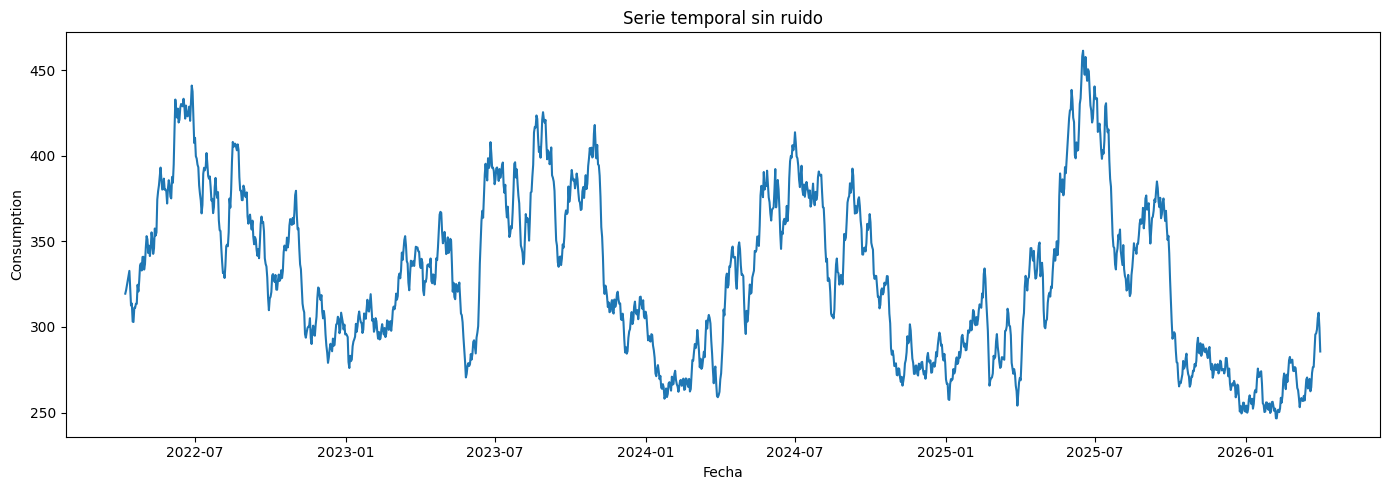

In [18]:
df_sinruido = (trend * seasonal).dropna().to_frame()
df_sinruido.index.name = 'Fecha'
df_sinruido.columns = ['Consumption']  # <- corrección

plt.figure(figsize=(14, 5))  # más ancho
plt.plot(df_sinruido)

plt.xlabel('Fecha')
plt.ylabel('Consumption')
plt.title('Serie temporal sin ruido')

plt.tight_layout()
plt.show()

Lag 1 -> RMSE: 0.0327 | MAE: 0.0259 | MAPE: 8.57%


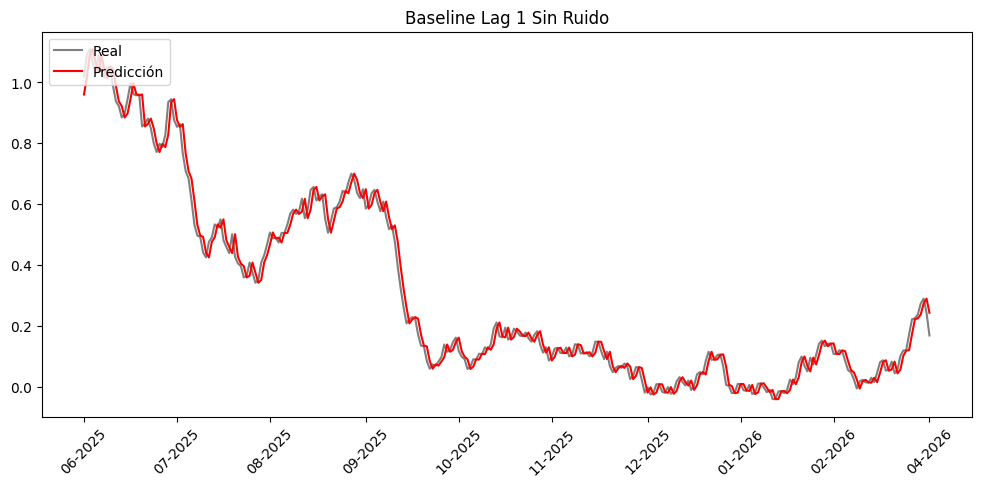

In [19]:
# Lag 1
dates1, y_true_1, y_pred_1 = baseline_persistence_scaled(df_sinruido, lag=1)
rmse1, mae1, mape1 = get_metrics(y_true_1, y_pred_1)
print(f"Lag 1 -> RMSE: {rmse1:.4f} | MAE: {mae1:.4f} | MAPE: {mape1:.2f}%")
plot_baseline(dates1, y_true_1, y_pred_1, "Baseline Lag 1 Sin Ruido")

Lag 7 -> RMSE: 0.1057 | MAE: 0.0749 | MAPE: 24.75%


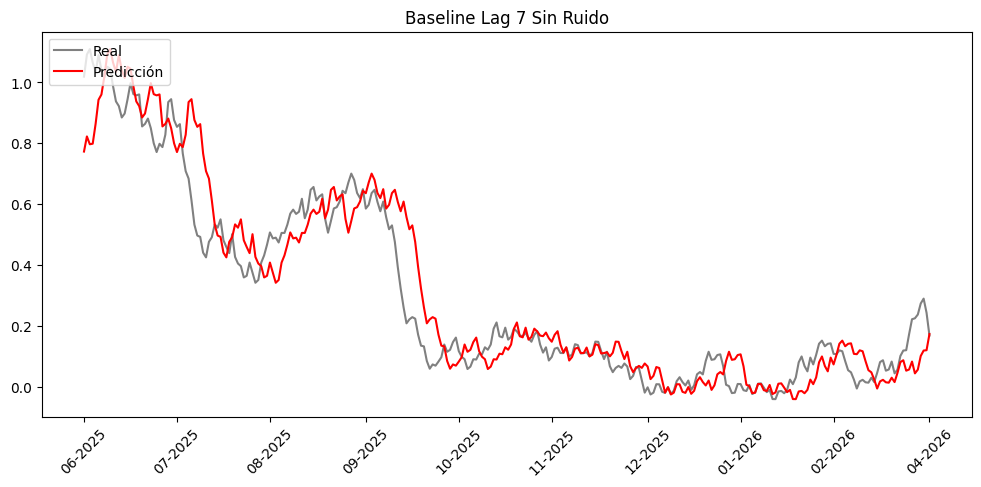

In [20]:
# Lag 7
dates7, y_true_7, y_pred_7 = baseline_persistence_scaled(df_sinruido, lag=7)
rmse7, mae7, mape7 = get_metrics(y_true_7, y_pred_7)
print(f"Lag 7 -> RMSE: {rmse7:.4f} | MAE: {mae7:.4f} | MAPE: {mape7:.2f}%")
plot_baseline(dates7, y_true_7, y_pred_7, "Baseline Lag 7 Sin Ruido")